In [1]:
# Hidden setup cell (imports, deterministic seed, global dt).
%matplotlib inline
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Fitting an EEG Model with Gradients

Whole-brain models have free parameters — coupling strengths, time constants, drive levels —
that must be **fit** so the model reproduces a measured signal. Historically this meant a
hand-rolled training loop copy-pasted into every script. This case study consolidates that
pattern into the one {class}`~brainmass.Fitter` API: *write the objective once, swap optimizer
backends.*

We fit a {class}`~brainmass.JansenRitStep` cortical-column model — the canonical generator of
EEG rhythms — so that the **oscillation amplitude** of its EEG output matches a target.

:::{important}
**Fit a scalar summary, not the raw waveform.** A gradient fitter that targets a raw
oscillatory time series fails: the model and target drift out of phase, the point-by-point RMSE
becomes flat/degenerate, and the gradient collapses to `nan`. The robust target is a **scalar
feature** of the signal — here the settled EEG oscillation amplitude. (The same lesson holds for
FC, spectral peak, or any phase-invariant summary.)
:::

**Source:** consolidates the hand-rolled `ModelFitting` EEG/MEG fitting scripts (Jansen-Rit
column driven to a recorded target) into {class}`~brainmass.Fitter`. Self-contained: the
"recorded" target is generated synthetically from a known ground-truth parameter, so the fit has
a checkable answer and needs no downloads.

## 1. The Jansen-Rit EEG model

A {class}`~brainmass.JansenRitStep` is a three-population (pyramidal / excitatory / inhibitory)
cortical column whose `eeg()` observable (`E − I`, in mV) oscillates in the alpha band under
constant excitatory drive. The dimensionless **connectivity constant `C`** scales the
intracortical excitatory/inhibitory loops and strongly controls the amplitude of the rhythm; we
treat it as the unknown to recover. (We fit a dimensionless parameter so the loss stays a plain
scalar — the same reason the gradient case studies fit `a` or `k`.)

First, a quick look at the EEG the model produces.

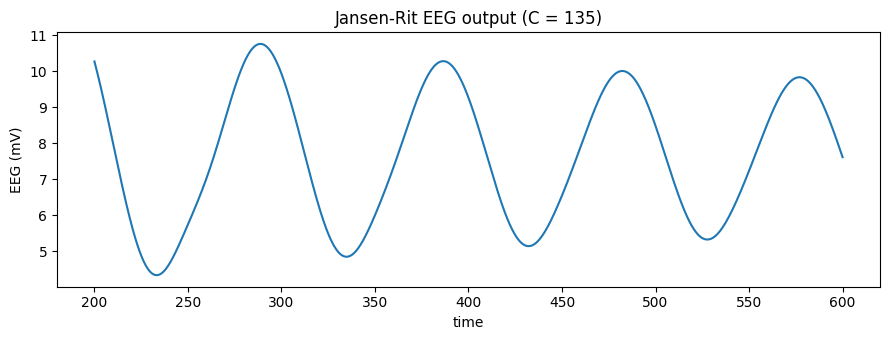

In [2]:
def run_jr(C, *, duration=600.0 * u.ms, seed=0):
    """Simulate one Jansen-Rit column and return (time, EEG trace in mV)."""
    brainstate.random.seed(seed)
    col = brainmass.JansenRitStep(in_size=1, C=C)
    sim = brainmass.Simulator(col, dt=0.1 * u.ms)
    res = sim.run(
        duration,
        inputs=lambda i, t: (0. * u.mV, 220. * u.Hz, 0. * u.mV),  # constant excitatory drive
        monitors=lambda m: m.eeg(),
        transient=200.0 * u.ms,
    )
    return res['ts'], res['output']

ts, eeg = run_jr(C=135.0)   # 135 is the canonical Jansen-Rit value
fig, ax = plt.subplots(figsize=(9, 3.5))
brainmass.viz.plot_timeseries(eeg, ts=ts, ax=ax)
ax.set_title('Jansen-Rit EEG output (C = 135)')
ax.set_ylabel('EEG (mV)')
plt.tight_layout()
plt.show()

## 2. The target and the scalar objective

Our "recording" is a Jansen-Rit EEG generated with a **ground-truth** `C* = 150`. We reduce both
prediction and target to a single phase-invariant feature — the **RMS amplitude** of the settled
oscillation — and fit `C` to match it. Because the amplitude grows smoothly and monotonically
with `C`, the loss surface is well conditioned for gradient descent.

target RMS amplitude (C*=150.0): 4.3312 mV


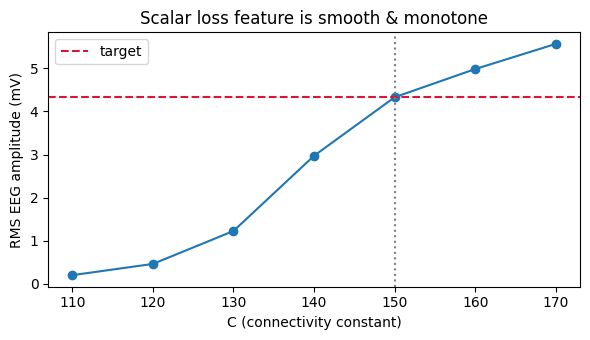

In [3]:
def rms_amplitude(eeg_trace):
    """Phase-invariant scalar feature: RMS of the (de-meaned) EEG, in mV (dimensionless number)."""
    x = u.get_magnitude(eeg_trace)
    x = x - jnp.mean(x)
    return jnp.sqrt(jnp.mean(x ** 2))

C_TRUE = 150.0
_, eeg_target = run_jr(C=C_TRUE, seed=7)
target_amp = rms_amplitude(eeg_target)
print(f"target RMS amplitude (C*={C_TRUE}): {float(target_amp):.4f} mV")

# Amplitude grows smoothly with C -> a well-conditioned scalar loss surface.
c_grid = np.linspace(110, 170, 7)
amps = [float(rms_amplitude(run_jr(C=c)[1])) for c in c_grid]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(c_grid, amps, 'o-')
ax.axhline(float(target_amp), color='crimson', ls='--', label='target')
ax.axvline(C_TRUE, color='grey', ls=':')
ax.set_xlabel('C (connectivity constant)'); ax.set_ylabel('RMS EEG amplitude (mV)')
ax.set_title('Scalar loss feature is smooth & monotone'); ax.legend()
plt.tight_layout()
plt.show()

## 3. Fit with the gradient backend

We mark `C` trainable with a {class}`~brainstate.nn.Param` and hand {class}`~brainmass.Fitter`
a `loss_fn(model) -> (scalar_loss, aux)`. The loss simulates the column, reduces the EEG to its
RMS amplitude, and squares the gap to the target — a scalar that brainmass differentiates
straight through the simulation (backprop-through-the-solve). The default `backend='grad'` drives
a `braintools.optim` Adam optimizer.

In [4]:
from brainstate.nn import Param

# Trainable column: C starts away from the truth (150) at 115.
brainstate.random.seed(0)
column = brainmass.JansenRitStep(in_size=1, C=Param(115.0, fit=True))

def loss_fn(model):
    sim = brainmass.Simulator(model, dt=0.1 * u.ms)
    res = sim.run(
        600.0 * u.ms,
        inputs=lambda i, t: (0. * u.mV, 220. * u.Hz, 0. * u.mV),
        monitors=lambda m: m.eeg(),
        transient=200.0 * u.ms,
    )
    amp = rms_amplitude(res['output'])
    loss = (amp - target_amp) ** 2
    return loss, amp

fitter = brainmass.Fitter(
    column,
    braintools.optim.Adam(lr=2.0),   # C lives on a ~100 scale, so a larger lr
    loss_fn=loss_fn,
    backend='grad',
)
result = fitter.fit(n_steps=40, verbose=False)

fitted_C = float(result.best_params['C'])
print(f"true  C : {C_TRUE:.2f}")
print(f"fitted C: {fitted_C:.2f}")
print(f"best loss: {result.best_loss:.3e}")

true  C : 150.00
fitted C: 151.51
best loss: 2.347e-04


## 4. Convergence and the recovered EEG

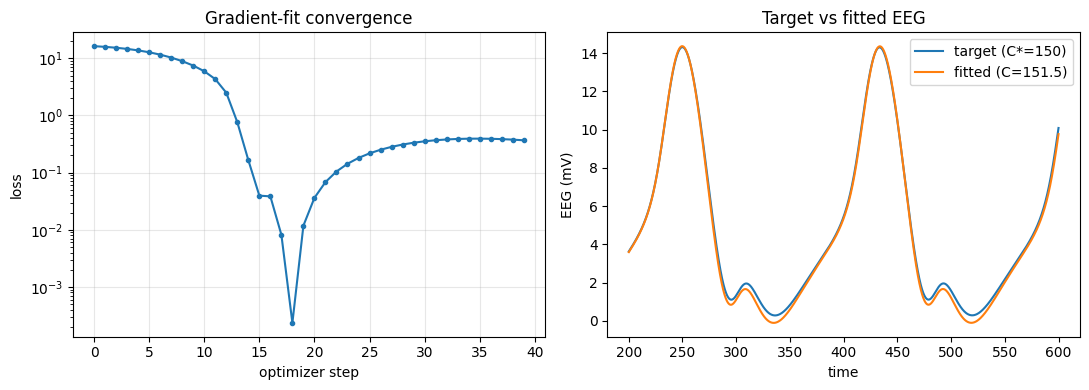

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(result.history, marker='.')
ax1.set_yscale('log'); ax1.set_xlabel('optimizer step'); ax1.set_ylabel('loss')
ax1.set_title('Gradient-fit convergence'); ax1.grid(alpha=0.3)

_, eeg_fit = run_jr(C=fitted_C, seed=7)
brainmass.viz.plot_timeseries(eeg_target, ts=ts, ax=ax2, labels=['target (C*=150)'])
brainmass.viz.plot_timeseries(eeg_fit, ts=ts, ax=ax2, labels=[f'fitted (C={fitted_C:.1f})'])
ax2.set_title('Target vs fitted EEG'); ax2.set_ylabel('EEG (mV)'); ax2.legend()
plt.tight_layout()
plt.show()

## 5. Swapping the backend (no objective rewrite)

The payoff of the {class}`~brainmass.Fitter` API: the *same* objective runs under a
derivative-free optimizer just by changing `backend`. Gradient-free search is the fallback when a
loss is non-differentiable or rugged. Here we give the search an explicit box for `C` and let
nevergrad's differential evolution find it.

In [6]:
try:
    import nevergrad  # noqa: F401
    has_ng = True
except ImportError:
    has_ng = False

if has_ng:
    brainstate.random.seed(0)
    column_ng = brainmass.JansenRitStep(in_size=1, C=Param(115.0, fit=True))

    def loss_fn_ng(model):
        sim = brainmass.Simulator(model, dt=0.1 * u.ms)
        res = sim.run(
            600.0 * u.ms,
            inputs=lambda i, t: (0. * u.mV, 220. * u.Hz, 0. * u.mV),
            monitors=lambda m: m.eeg(), transient=200.0 * u.ms)
        amp = rms_amplitude(res['output'])
        return (amp - target_amp) ** 2, amp

    fitter_ng = brainmass.Fitter(
        column_ng, {'method': 'DE', 'n_sample': 6},
        loss_fn=loss_fn_ng, backend='nevergrad',
        search_space={'C': (110.0, 170.0)},
    )
    result_ng = fitter_ng.fit(n_steps=8, verbose=False)
    print(f"gradient   : C = {fitted_C:.2f}")
    print(f"nevergrad  : C = {float(result_ng.best_params['C']):.2f}")
else:
    print("nevergrad not installed; gradient backend gave C =", f"{fitted_C:.2f}")

gradient   : C = 151.51
nevergrad  : C = 150.01


## Summary

We fit a Jansen-Rit EEG model to a target by:

1. picking a **scalar, phase-invariant feature** (RMS amplitude) of the EEG — *never* the raw
   oscillatory waveform, which makes the gradient degenerate,
2. wrapping the unknown connectivity constant `C` in a trainable {class}`~brainstate.nn.Param`
   (a dimensionless knob, so the loss stays a plain scalar),
3. handing one `loss_fn` to {class}`~brainmass.Fitter` with `backend='grad'`, which
   backpropagates through the whole simulation, and
4. recovering the ground-truth `C` and confirming the convergence curve.

The same objective ran under a derivative-free backend with a one-line change — the consolidation
that replaced the hand-rolled fitting scripts. For fitting a *network* to functional connectivity
instead of a single column, swap the scalar feature for
{func}`brainmass.objectives.fc_corr(as_loss=True) <brainmass.objectives.fc_corr>` and fit the
coupling strength `k`.